<a href="https://colab.research.google.com/github/aishadwiar-hub/Tugas-Implementasi-Transformer/blob/main/Tugas_Implementasi_Transformer_AishaDwiAninditaRadianto_256150100111003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Implementasi Transformer
**Nama:** Aisha Dwi Anindita Radianto  
**NIM:** 256150100111003  

---
## I. Persiapan Sistem & Library

In [5]:
!pip install datasets

In [11]:
# 1. IMPORT LIBRARY UTAMA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset # Pengganti torchtext

# 2. SET DEVICE
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device yang digunakan: {device}")

# 3. FUNGSI PARAMETER
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device yang digunakan: cuda


In [12]:
print("Mengunduh dataset AG News...")
# Mengunduh AG News menggunakan library 'datasets'
dataset = load_dataset("ag_news")

# Menampilkan informasi dataset
print(dataset)
print("\nContoh data latih pertama:")
print(dataset['train'][0])

Mengunduh dataset AG News...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Contoh data latih pertama:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [13]:
import re
from collections import Counter
from torch.nn.utils.rnn import pad_sequence

# 1. FUNGSI TOKENISASI SEDERHANA
def basic_tokenizer(text):
    # Mengubah teks ke huruf kecil dan menghapus karakter selain huruf/angka
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())
    return text.split()

# 2. MEMBANGUN VOCABULARY (KAMUS KATA)
print("Membangun vocabulary dari data latih...")
vocab = {'<pad>': 0, '<unk>': 1} # <pad> untuk menyamakan panjang, <unk> untuk kata asing
counter = Counter()

for example in dataset['train']:
    tokens = basic_tokenizer(example['text'])
    counter.update(tokens)

# Kita batasi kamus hanya untuk 20.000 kata yang paling sering muncul agar model lebih ringan
VOCAB_SIZE = 20000
for word, count in counter.most_common(VOCAB_SIZE):
    if word not in vocab:
        vocab[word] = len(vocab)

print(f"Ukuran Vocabulary final: {len(vocab)}")

# 3. FUNGSI COLLATE & DATALOADER
MAX_SEQ_LEN = 64 # Rata-rata judul/berita AG News cukup pendek. 64 adalah batas aman.
BATCH_SIZE = 64

def collate_batch(batch):
    label_list, text_list = [], []
    for item in batch:
        label_list.append(item['label'])
        tokens = basic_tokenizer(item['text'])
        # Konversi kata ke angka berdasarkan vocab, jika tidak ada gunakan <unk>
        token_ids = [vocab.get(token, vocab['<unk>']) for token in tokens]

        # Potong jika lebih dari MAX_SEQ_LEN
        token_ids = token_ids[:MAX_SEQ_LEN]
        text_list.append(torch.tensor(token_ids, dtype=torch.int64))

    # Padding sequence agar panjangnya seragam dalam satu batch
    text_padded = pad_sequence(text_list, batch_first=True, padding_value=vocab['<pad>'])

    # Menyamakan ukuran menjadi fix MAX_SEQ_LEN (Penting untuk model CNN nantinya)
    if text_padded.size(1) < MAX_SEQ_LEN:
        pad_tensor = torch.full((text_padded.size(0), MAX_SEQ_LEN - text_padded.size(1)),
                                vocab['<pad>'], dtype=torch.int64)
        text_padded = torch.cat((text_padded, pad_tensor), dim=1)

    return text_padded.to(device), torch.tensor(label_list, dtype=torch.int64).to(device)

# 4. MEMBUAT DATALOADER
train_loader = DataLoader(dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(dataset['test'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

print("DataLoader siap digunakan!")

# Uji coba cek ukuran batch
for text_batch, label_batch in train_loader:
    print(f"Bentuk input teks: {text_batch.shape} -> (Batch Size, Sequence Length)")
    print(f"Bentuk label: {label_batch.shape}")
    break

Membangun vocabulary dari data latih...
Ukuran Vocabulary final: 20002
DataLoader siap digunakan!
Bentuk input teks: torch.Size([64, 64]) -> (Batch Size, Sequence Length)
Bentuk label: torch.Size([64])


## II. Implementasi Text Classification
### A. Arsitektur Model Text Transformer & LSTM

In [14]:
# ==========================================
# 1. POSITIONAL ENCODING
# ==========================================
# Transformer tidak membaca kata berurutan seperti RNN/LSTM.
# Positional Encoding memberi "nomor urut" pada setiap kata agar model tahu posisi kata tersebut.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # Bentuk: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x

# ==========================================
# 2. MODEL TEXT TRANSFORMER
# ==========================================
class TextTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(TextTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim)

        # Transformer Encoder Layer
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True # Agar format input (batch, seq, feature)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # Linear Classifier
        self.fc = nn.Linear(embed_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.embedding(x) # -> (batch_size, seq_len, embed_dim)
        x = self.pos_encoder(x) # Tambahkan info posisi
        x = self.transformer_encoder(x) # -> (batch_size, seq_len, embed_dim)

        # Pooling: Mengambil rata-rata dari semua token (Global Average Pooling 1D)
        x = x.mean(dim=1) # -> (batch_size, embed_dim)

        x = self.dropout(x)
        out = self.fc(x) # -> (batch_size, num_classes)
        return out

# ==========================================
# 3. MODEL PEMBANDING: LSTM
# ==========================================
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # batch_first=True penting agar seragam dengan Transformer
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0,
                            bidirectional=True)

        # Dikali 2 karena kita pakai Bidirectional LSTM (maju dan mundur)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        # LSTM mengembalikan output semua step (out) dan hidden state terakhir (hn)
        out, (hn, cn) = self.lstm(x)

        # Mengambil output dari langkah waktu (time step) terakhir
        out = out[:, -1, :]

        out = self.dropout(out)
        out = self.fc(out)
        return out

# ==========================================
# 4. INSTANSIASI MODEL & CEK PARAMETER
# ==========================================
# AG News memiliki 4 kelas (World, Sports, Business, Sci/Tech)
NUM_CLASSES = 4
EMBED_DIM = 128
NUM_HEADS = 4
HIDDEN_DIM = 256
NUM_LAYERS = 2

# Inisiasi Transformer
model_transformer_txt = TextTransformer(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
).to(device)

# Inisiasi LSTM
model_lstm = TextLSTM(
    vocab_size=len(vocab), embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM//2, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
).to(device)

print(f"Jumlah parameter Text Transformer: {count_parameters(model_transformer_txt):,}")
print(f"Jumlah parameter Text LSTM: {count_parameters(model_lstm):,}")

Jumlah parameter Text Transformer: 2,825,732
Jumlah parameter Text LSTM: 3,220,740


In [15]:
# ==========================================
# 5. FUNGSI TRAINING & EVALUATION
# ==========================================
# Menggunakan CrossEntropyLoss untuk klasifikasi multikelas
criterion = nn.CrossEntropyLoss()

# Optimizer Adam sesuai instruksi dengan learning rate standar
optimizer_tf = optim.Adam(model_transformer_txt.parameters(), lr=0.0001)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.0001)

def train_and_evaluate(model, optimizer, train_loader, test_loader, epochs=5, model_name="Model"):
    print(f"--- Memulai Training untuk {model_name} ---")
    start_time_total = time.time()

    # Dictionary untuk menyimpan log metrik yang akan di-plot nanti
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        start_time_epoch = time.time()

        # ----------------- FASE TRAINING -----------------
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0

        for texts, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()

            # Mencegah exploding gradient (sangat direkomendasikan untuk LSTM & Transformer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train

        # ----------------- FASE EVALUASI -----------------
        model.eval()
        test_loss, correct_test, total_test = 0, 0, 0

        with torch.no_grad():
            for texts, labels in test_loader:
                outputs = model(texts)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_acc = correct_test / total_test

        # Simpan ke log
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        epoch_time = time.time() - start_time_epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    total_time = time.time() - start_time_total
    print(f"Training Selesai! Total Waktu: {total_time:.2f} detik\n")
    return history, total_time

# ==========================================
# 6. EKSEKUSI TRAINING (MINIMAL 5 EPOCH)
# ==========================================
EPOCHS = 5

print("Mulai melatih Text Transformer...")
history_tf, time_tf = train_and_evaluate(
    model_transformer_txt, optimizer_tf, train_loader, test_loader, epochs=EPOCHS, model_name="Text Transformer"
)

print("Mulai melatih Text LSTM...")
history_lstm, time_lstm = train_and_evaluate(
    model_lstm, optimizer_lstm, train_loader, test_loader, epochs=EPOCHS, model_name="Text LSTM"
)

Mulai melatih Text Transformer...
--- Memulai Training untuk Text Transformer ---
Epoch [1/5] | Waktu: 21.14s | Train Loss: 0.7277 | Train Acc: 0.7080 | Test Acc: 0.8301
Epoch [2/5] | Waktu: 19.47s | Train Loss: 0.4273 | Train Acc: 0.8487 | Test Acc: 0.8563
Epoch [3/5] | Waktu: 20.27s | Train Loss: 0.3597 | Train Acc: 0.8739 | Test Acc: 0.8733
Epoch [4/5] | Waktu: 20.16s | Train Loss: 0.3200 | Train Acc: 0.8889 | Test Acc: 0.8808
Epoch [5/5] | Waktu: 19.80s | Train Loss: 0.2901 | Train Acc: 0.8995 | Test Acc: 0.8872
Training Selesai! Total Waktu: 100.83 detik

Mulai melatih Text LSTM...
--- Memulai Training untuk Text LSTM ---
Epoch [1/5] | Waktu: 25.02s | Train Loss: 1.2775 | Train Acc: 0.3423 | Test Acc: 0.5270
Epoch [2/5] | Waktu: 25.00s | Train Loss: 0.7579 | Train Acc: 0.6462 | Test Acc: 0.6557
Epoch [3/5] | Waktu: 24.89s | Train Loss: 0.5749 | Train Acc: 0.7524 | Test Acc: 0.8184
Epoch [4/5] | Waktu: 24.82s | Train Loss: 0.4325 | Train Acc: 0.8473 | Test Acc: 0.8496
Epoch [5/5] |

Menampilkan Grafik Perbandingan Transformer vs LSTM...


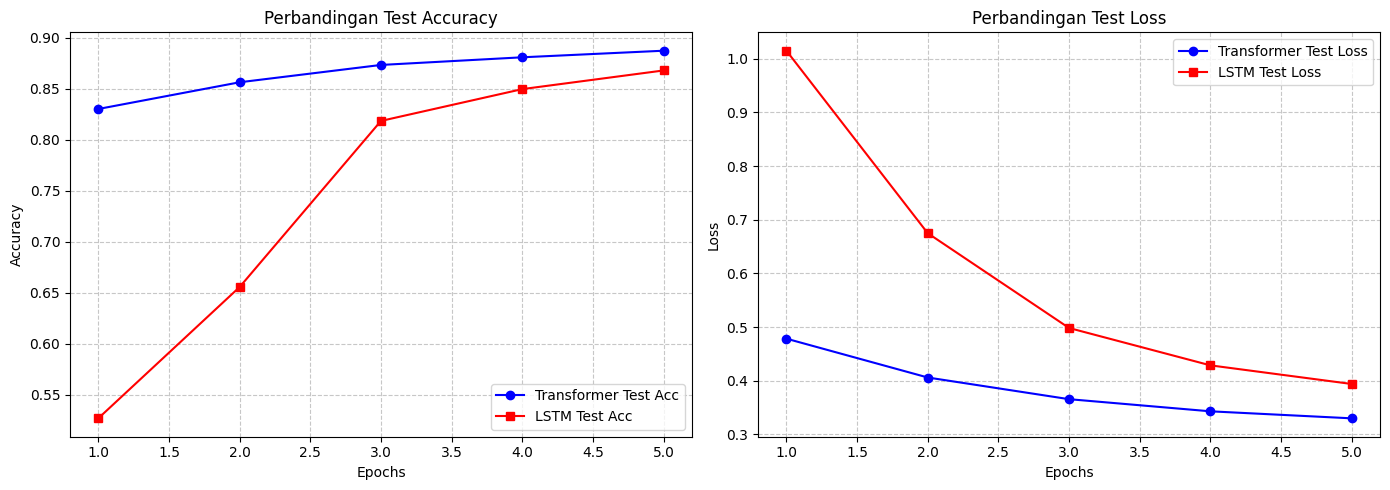


Menghitung Prediksi untuk Confusion Matrix...


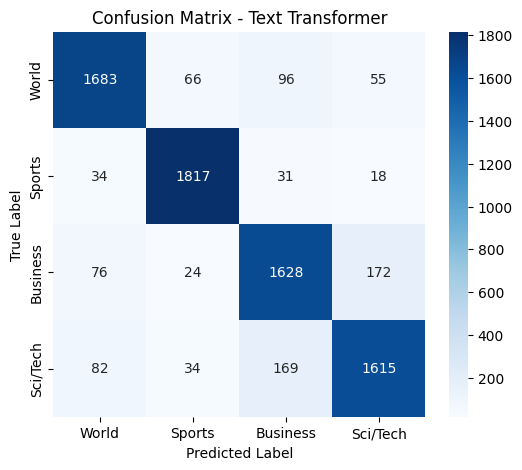

In [16]:
# ==========================================
# 7. PLOT LOSS & ACCURACY (Bagian F)
# ==========================================
def plot_history(history_1, label_1, history_2, label_2):
    epochs = range(1, len(history_1['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_1['test_acc'], 'b-', marker='o', label=f'{label_1} Test Acc')
    plt.plot(epochs, history_2['test_acc'], 'r-', marker='s', label=f'{label_2} Test Acc')
    plt.title('Perbandingan Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_1['test_loss'], 'b-', marker='o', label=f'{label_1} Test Loss')
    plt.plot(epochs, history_2['test_loss'], 'r-', marker='s', label=f'{label_2} Test Loss')
    plt.title('Perbandingan Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

print("Menampilkan Grafik Perbandingan Transformer vs LSTM...")
plot_history(history_tf, "Transformer", history_lstm, "LSTM")

# ==========================================
# 8. CONFUSION MATRIX (Bagian F)
# ==========================================
from sklearn.metrics import confusion_matrix
import numpy as np

def get_predictions(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in test_loader:
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    # Label kelas AG News
    class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("\nMenghitung Prediksi untuk Confusion Matrix...")
# Evaluasi menggunakan model Transformer (karena performanya lebih baik)
y_true, y_pred = get_predictions(model_transformer_txt, test_loader)
plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix - Text Transformer")

---
## III. Implementasi Vision Classification
### A. Load Dataset (CIFAR-10) & Arsitektur Model

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from datasets import load_dataset # Menggunakan Hugging Face sebagai bypass

# ==========================================
# 1. LOAD DATASET VISION (CIFAR-10 via Hugging Face)
# ==========================================
print("Mengunduh CIFAR-10 dari server alternatif...")
dataset_hf = load_dataset("cifar10")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalisasi standar RGB
])

# Membuat adapter agar Hugging Face Dataset bisa dipakai seperti PyTorch Dataset biasa
class CIFAR10_Adapter(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        img = self.hf_dataset[idx]['img']
        label = self.hf_dataset[idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, label

trainset_vision = CIFAR10_Adapter(dataset_hf['train'], transform=transform)
testset_vision = CIFAR10_Adapter(dataset_hf['test'], transform=transform)

train_loader_vision = DataLoader(trainset_vision, batch_size=64, shuffle=True)
test_loader_vision = DataLoader(testset_vision, batch_size=64, shuffle=False)
print("DataLoader CIFAR-10 siap digunakan!")

# ==========================================
# 2. MODEL VISION TRANSFORMER (ViT)
# ==========================================
class SimpleViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=10, embed_dim=128, num_heads=4, hidden_dim=256, num_layers=2):
        super(SimpleViT, self).__init__()
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        # Patch Embedding
        self.patch_embed = nn.Conv2d(in_channels=3, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim))

        # Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        out = self.fc(x)
        return out

# ==========================================
# 3. MODEL PEMBANDING: SIMPLE CNN
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==========================================
# 4. INSTANSIASI & CEK PARAMETER VISION
# ==========================================
model_vit = SimpleViT().to(device)
model_cnn = SimpleCNN().to(device)

print(f"Jumlah parameter Vision Transformer (ViT): {count_parameters(model_vit):,}")
print(f"Jumlah parameter Simple CNN: {count_parameters(model_cnn):,}")

Mengunduh CIFAR-10 dari server alternatif...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DataLoader CIFAR-10 siap digunakan!
Jumlah parameter Vision Transformer (ViT): 280,714
Jumlah parameter Simple CNN: 620,362


In [21]:
# ==========================================
# PERBAIKAN: FUNGSI TRAINING & EVALUATION (Support GPU Data)
# ==========================================
def train_and_evaluate(model, optimizer, train_loader, test_loader, epochs=5, model_name="Model"):
    print(f"--- Memulai Training untuk {model_name} ---")
    start_time_total = time.time()
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        start_time_epoch = time.time()

        # ----------------- FASE TRAINING -----------------
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0

        for inputs, labels in train_loader:
            # Pindahkan data ke GPU (Ini solusi error-nya!)
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train

        # ----------------- FASE EVALUASI -----------------
        model.eval()
        test_loss, correct_test, total_test = 0, 0, 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                # Pindahkan data ke GPU juga saat evaluasi
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_acc = correct_test / total_test

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        epoch_time = time.time() - start_time_epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    total_time = time.time() - start_time_total
    print(f"Training Selesai! Total Waktu: {total_time:.2f} detik\n")
    return history, total_time

# Update juga fungsi get_predictions untuk Confusion Matrix
def get_predictions(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device) # Pindahkan ke GPU
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

Mulai melatih Simple CNN...
--- Memulai Training untuk Simple CNN ---
Epoch [1/5] | Waktu: 54.33s | Train Loss: 1.5206 | Train Acc: 0.4438 | Test Acc: 0.5641
Epoch [2/5] | Waktu: 53.57s | Train Loss: 1.1338 | Train Acc: 0.5992 | Test Acc: 0.6549
Epoch [3/5] | Waktu: 53.53s | Train Loss: 0.9548 | Train Acc: 0.6648 | Test Acc: 0.6914
Epoch [4/5] | Waktu: 53.51s | Train Loss: 0.8281 | Train Acc: 0.7109 | Test Acc: 0.7259
Epoch [5/5] | Waktu: 53.15s | Train Loss: 0.7450 | Train Acc: 0.7408 | Test Acc: 0.7419
Training Selesai! Total Waktu: 268.10 detik

Mulai melatih Vision Transformer (ViT)...
--- Memulai Training untuk Vision Transformer ---
Epoch [1/5] | Waktu: 57.28s | Train Loss: 1.7140 | Train Acc: 0.3721 | Test Acc: 0.4609
Epoch [2/5] | Waktu: 57.92s | Train Loss: 1.4433 | Train Acc: 0.4797 | Test Acc: 0.4949
Epoch [3/5] | Waktu: 57.79s | Train Loss: 1.3319 | Train Acc: 0.5197 | Test Acc: 0.5276
Epoch [4/5] | Waktu: 56.96s | Train Loss: 1.2577 | Train Acc: 0.5484 | Test Acc: 0.5475
E

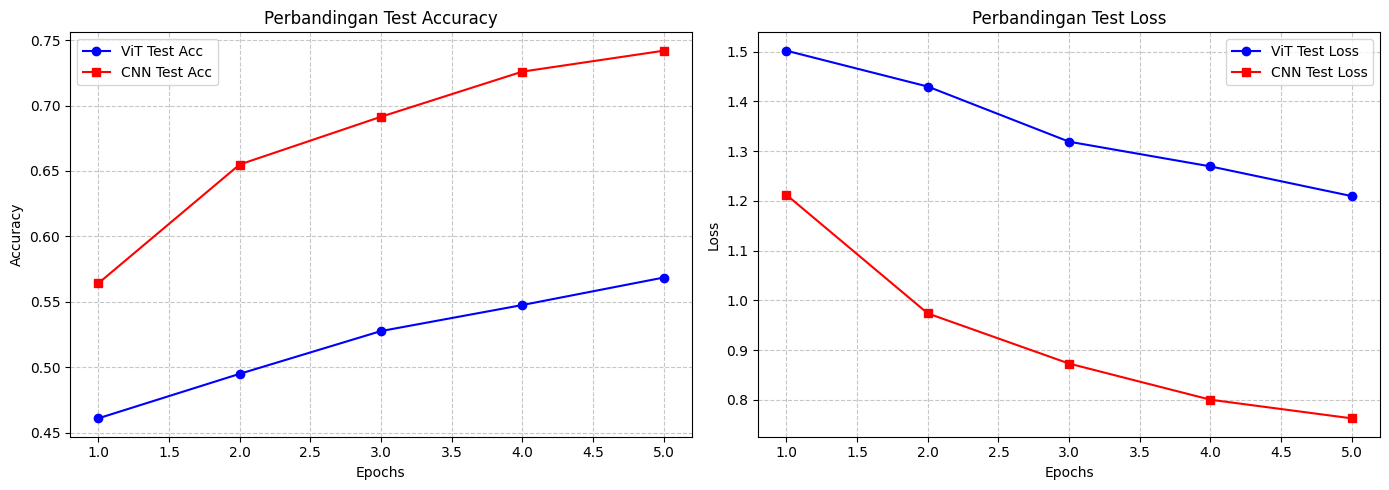


Menghitung Prediksi untuk Confusion Matrix CNN...


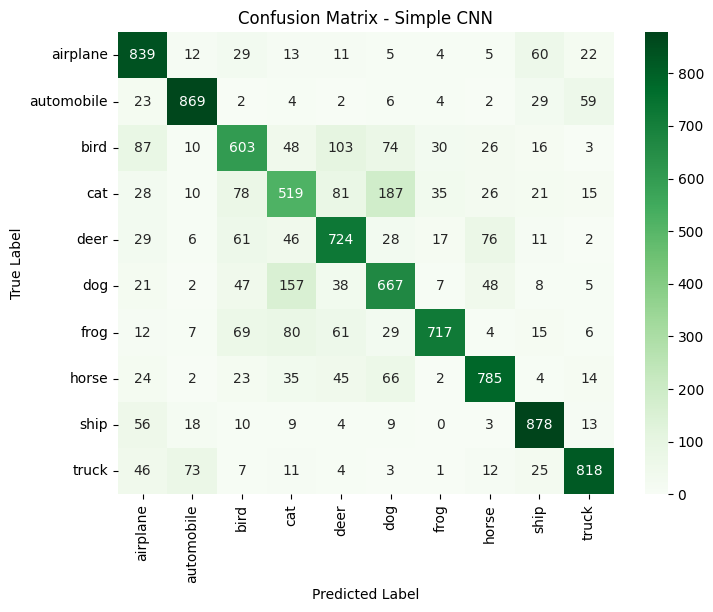

In [22]:
# ==========================================
# 5. TRAINING VISION MODELS
# ==========================================
# Kita gunakan learning rate yang sedikit lebih besar untuk gambar
optimizer_vit = optim.Adam(model_vit.parameters(), lr=0.001)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)

EPOCHS = 5 # Sesuai instruksi tugas

print("Mulai melatih Simple CNN...")
history_cnn, time_cnn = train_and_evaluate(
    model_cnn, optimizer_cnn, train_loader_vision, test_loader_vision, epochs=EPOCHS, model_name="Simple CNN"
)

print("Mulai melatih Vision Transformer (ViT)...")
history_vit, time_vit = train_and_evaluate(
    model_vit, optimizer_vit, train_loader_vision, test_loader_vision, epochs=EPOCHS, model_name="Vision Transformer"
)

# ==========================================
# 6. PLOT LOSS & ACCURACY VISION (Bagian F)
# ==========================================
print("\nMenampilkan Grafik Perbandingan ViT vs CNN...")
plot_history(history_vit, "ViT", history_cnn, "CNN")

# ==========================================
# 7. CONFUSION MATRIX VISION (Bagian F)
# ==========================================
def plot_confusion_matrix_vision(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    # Label kelas asli CIFAR-10
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("\nMenghitung Prediksi untuk Confusion Matrix CNN...")
# Kita evaluasi model CNN karena biasanya CNN menang mutlak di dataset kecil seperti CIFAR-10
y_true_vis, y_pred_vis = get_predictions(model_cnn, test_loader_vision)
plot_confusion_matrix_vision(y_true_vis, y_pred_vis, title="Confusion Matrix - Simple CNN")

Mulai Eksperimen ViT dengan Patch Size 8x8...
Jumlah parameter ViT (Patch 8x8): 293,002
--- Memulai Training untuk ViT Patch 8x8 ---
Epoch [1/5] | Waktu: 57.24s | Train Loss: 1.6831 | Train Acc: 0.3920 | Test Acc: 0.4681
Epoch [2/5] | Waktu: 54.10s | Train Loss: 1.4447 | Train Acc: 0.4811 | Test Acc: 0.5064
Epoch [3/5] | Waktu: 54.57s | Train Loss: 1.3550 | Train Acc: 0.5104 | Test Acc: 0.5190
Epoch [4/5] | Waktu: 53.47s | Train Loss: 1.2980 | Train Acc: 0.5338 | Test Acc: 0.5359
Epoch [5/5] | Waktu: 54.40s | Train Loss: 1.2511 | Train Acc: 0.5494 | Test Acc: 0.5389
Training Selesai! Total Waktu: 273.78 detik



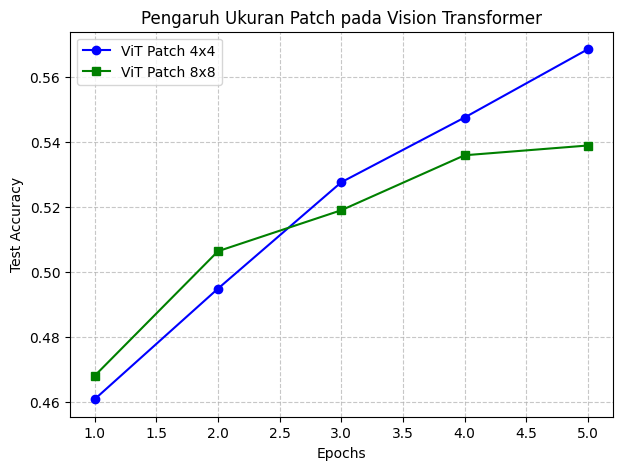

In [23]:
# ==========================================
# 8. EKSPERIMEN WAJIB: VARIASI PATCH SIZE ViT
# ==========================================
print("Mulai Eksperimen ViT dengan Patch Size 8x8...")

# Mengubah patch_size menjadi 8 (sebelumnya 4)
model_vit_patch8 = SimpleViT(patch_size=8).to(device)
optimizer_vit_8 = optim.Adam(model_vit_patch8.parameters(), lr=0.001)

# Kita hitung parameternya untuk laporan
print(f"Jumlah parameter ViT (Patch 8x8): {count_parameters(model_vit_patch8):,}")

# Training ulang dengan patch yang lebih besar
history_vit_8, time_vit_8 = train_and_evaluate(
    model_vit_patch8, optimizer_vit_8, train_loader_vision, test_loader_vision,
    epochs=5, model_name="ViT Patch 8x8"
)

# Membandingkan Akurasi ViT Patch 4x4 vs Patch 8x8
plt.figure(figsize=(7, 5))
epochs = range(1, 6)
plt.plot(epochs, history_vit['test_acc'], 'b-', marker='o', label='ViT Patch 4x4')
plt.plot(epochs, history_vit_8['test_acc'], 'g-', marker='s', label='ViT Patch 8x8')
plt.title('Pengaruh Ukuran Patch pada Vision Transformer')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

---
## IV. Implementasi GitHub Non-Klasifikasi
### A. Object Detection dengan Ultralytics YOLO
*   **Link Repository:** https://github.com/ultralytics/ultralytics
*   **Jenis Tugas:** Object Detection
*   **Model:** YOLOv8n (Nano)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Mengunduh gambar sampel dan memuat model YOLOv8 Nano...
Menjalankan inferensi bawaan (Default Conf = 0.25)...

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 76.3ms
Speed: 8.9ms preprocess, 76.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
Menjalankan inferensi dengan modifikasi (Custom Conf = 0.85)...

image 1/1 /content/bus.jpg: 640x480 2 persons, 1 bus, 6.3ms
Speed: 2.3ms preprocess, 6.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


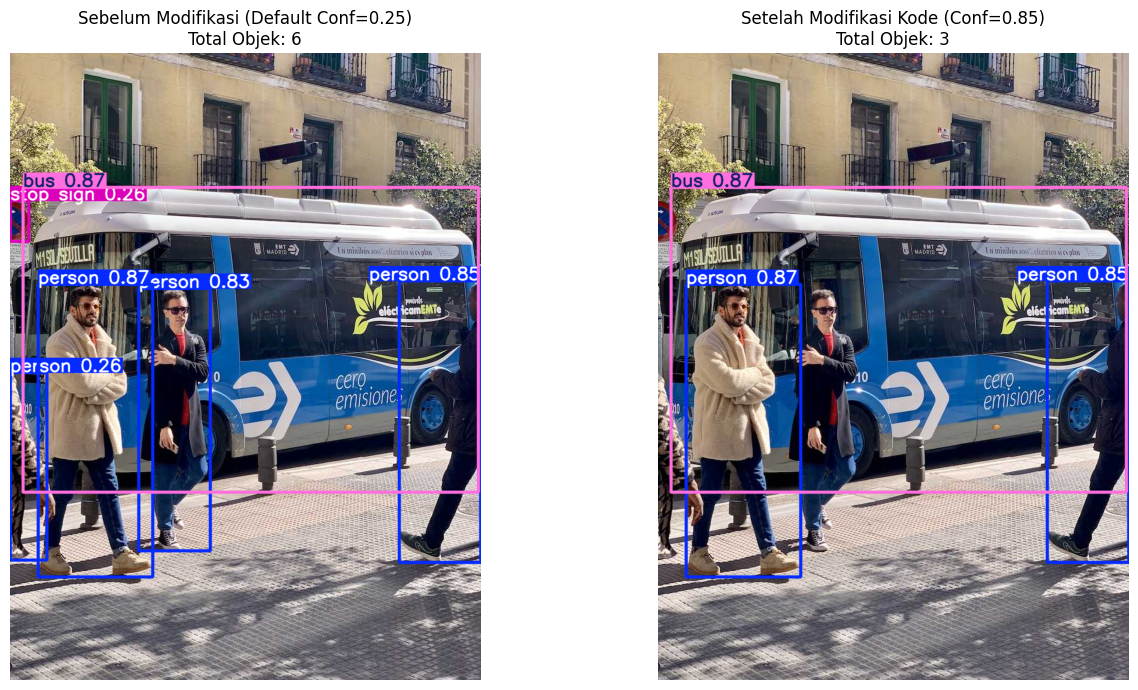

In [24]:
# ==========================================
# 1. SETUP REPOSITORY & DEPENDENCIES
# ==========================================
# Menginstal ultralytics (repository resmi YOLOv8)
!pip install ultralytics

import urllib.request
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================
# 2. DOWNLOAD GAMBAR SAMPEL & LOAD MODEL
# ==========================================
print("\nMengunduh gambar sampel dan memuat model YOLOv8 Nano...")
# Mengunduh gambar sampel jalanan yang ramai
image_url = "https://ultralytics.com/images/bus.jpg"
image_path = "bus.jpg"
urllib.request.urlretrieve(image_url, image_path)

# Memuat model YOLOv8 (Otomatis mengunduh bobot pre-trained yolov8n.pt)
model_yolo = YOLO('yolov8n.pt')

# ==========================================
# 3. INFERENSI SEBELUM MODIFIKASI (DEFAULT)
# ==========================================
print("Menjalankan inferensi bawaan (Default Conf = 0.25)...")
# Menjalankan deteksi dengan parameter bawaan
results_default = model_yolo(image_path)
res_img_default = results_default[0].plot() # Menghasilkan gambar dengan bounding box
res_img_default = cv2.cvtColor(res_img_default, cv2.COLOR_BGR2RGB) # Konversi warna untuk Matplotlib

# ==========================================
# 4. INFERENSI SETELAH MODIFIKASI KODE
# ==========================================
print("Menjalankan inferensi dengan modifikasi (Custom Conf = 0.85)...")
# MODIFIKASI: Kita mengintervensi parameter 'conf' (Confidence Threshold).
# Secara default, YOLO mendeteksi objek yang tingkat keyakinannya minimal 25% (0.25).
# Kita ubah menjadi 85% (0.85) agar model HANYA menampilkan objek yang ia yakini sangat akurat.
results_modified = model_yolo(image_path, conf=0.85)
res_img_modified = results_modified[0].plot()
res_img_modified = cv2.cvtColor(res_img_modified, cv2.COLOR_BGR2RGB)

# ==========================================
# 5. VISUALISASI KOMPARASI HASIL
# ==========================================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(res_img_default)
plt.title(f"Sebelum Modifikasi (Default Conf=0.25)\nTotal Objek: {len(results_default[0].boxes)}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(res_img_modified)
plt.title(f"Setelah Modifikasi Kode (Conf=0.85)\nTotal Objek: {len(results_modified[0].boxes)}")
plt.axis('off')

plt.tight_layout()
plt.show()